# 01 — Exploratory Data Analysis
## Multi-Attribute Scene Classification on nuScenes Front-Camera Images

**Project:** Multi-Attribute Scene Classification of Front-Camera Driving Images: A Comparative Classical Machine Learning Study on the nuScenes Dataset.

**This notebook:** Surveys the dataset to understand class distributions, image properties, and prepares for downstream feature extraction.

### Dataset
- nuScenes v1.0-mini (development) — 10 scenes, 404 keyframes, 6 cameras
- We use only **CAM_FRONT** images
- v1.0-trainval will be used in scale-up phase

### Outputs
- Class-distribution plots for each scene attribute
- Sample images per class
- Image-statistics summary (size, mean/std, brightness)
- Scene-level metadata table

## 0. Setup

In [1]:
import os
import json
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


In [2]:
# --- Configuration ---
DATASET_VERSION = 'v1.0-mini'   # change to 'v1.0-trainval' when scaling up
DATAROOT = Path('data/') / DATASET_VERSION
FIG_DIR  = Path('results/figures/eda')
META_DIR = Path('data/metadata')
for p in [FIG_DIR, META_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'DATAROOT        = {DATAROOT}')
print(f'  exists:        {DATAROOT.exists()}')

DATASET_VERSION = v1.0-mini
DATAROOT        = data/v1.0-mini
  exists:        True


## 1. Load nuScenes Devkit

In [3]:
from nuscenes.nuscenes import NuScenes
nusc = NuScenes(version=DATASET_VERSION, dataroot=str(DATAROOT), verbose=False)

print(f'Loaded {DATASET_VERSION}')
print(f'  scenes:    {len(nusc.scene)}')
print(f'  samples:   {len(nusc.sample)}')
print(f'  sample_data: {len(nusc.sample_data)}')
print(f'  annotations: {len(nusc.sample_annotation)}')
print(f'  log entries: {len(nusc.log)}')

Loaded v1.0-mini
  scenes:    10
  samples:   404
  sample_data: 31206
  annotations: 18538
  log entries: 8


## 2. Build Per-Sample Metadata Table

We construct one row per CAM_FRONT keyframe with everything we need downstream — image path, scene token, scene description, location, capture time.

In [4]:
rows = []
for sample in nusc.sample:
    scene = nusc.get('scene', sample['scene_token'])
    log   = nusc.get('log', scene['log_token'])
    sd    = nusc.get('sample_data', sample['data']['CAM_FRONT'])

    rows.append({
        'sample_token': sample['token'],
        'scene_token':  sample['scene_token'],
        'scene_name':   scene['name'],
        'scene_description': scene['description'],
        'location':     log['location'],
        'vehicle':      log['vehicle'],
        'date_captured': log['date_captured'],
        'image_path':   str(DATAROOT / sd['filename']),
        'image_filename': sd['filename'],
        'timestamp':    sample['timestamp'],
    })

df_meta = pd.DataFrame(rows)
print(f'Total CAM_FRONT keyframes: {len(df_meta)}')
print(f'Unique scenes: {df_meta["scene_token"].nunique()}')
df_meta.head()

Total CAM_FRONT keyframes: 404
Unique scenes: 10


,sample_token,scene_token,scene_name,scene_description,location,vehicle,date_captured,image_path,image_filename,timestamp
0,ca9a282c9e77460f8360f564131a8af5,cc8c0bf57f984915a77078b10eb33198,scene-0061,"Parked truck, construction, intersection, turn...",singapore-onenorth,n015,2018-07-24,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,samples/CAM_FRONT/n015-2018-07-24-11-22-45+080...,1532402927647951
1,39586f9d59004284a7114a68825e8eec,cc8c0bf57f984915a77078b10eb33198,scene-0061,"Parked truck, construction, intersection, turn...",singapore-onenorth,n015,2018-07-24,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,samples/CAM_FRONT/n015-2018-07-24-11-22-45+080...,1532402928147847
2,356d81f38dd9473ba590f39e266f54e5,cc8c0bf57f984915a77078b10eb33198,scene-0061,"Parked truck, construction, intersection, turn...",singapore-onenorth,n015,2018-07-24,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,samples/CAM_FRONT/n015-2018-07-24-11-22-45+080...,1532402928698048
3,e0845f5322254dafadbbed75aaa07969,cc8c0bf57f984915a77078b10eb33198,scene-0061,"Parked truck, construction, intersection, turn...",singapore-onenorth,n015,2018-07-24,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,samples/CAM_FRONT/n015-2018-07-24-11-22-45+080...,1532402929197353
4,c923fe08b2ff4e27975d2bf30934383b,cc8c0bf57f984915a77078b10eb33198,scene-0061,"Parked truck, construction, intersection, turn...",singapore-onenorth,n015,2018-07-24,data/v1.0-mini/samples/CAM_FRONT/n015-2018-07-...,samples/CAM_FRONT/n015-2018-07-24-11-22-45+080...,1532402929697797


In [5]:
# Save raw metadata
df_meta.to_csv(META_DIR / 'sample_metadata.csv', index=False)
print(f'Saved → {META_DIR / "sample_metadata.csv"}')

Saved → data/metadata/sample_metadata.csv


## 3. Scene-Description Analysis

The scene `description` field contains free-text describing weather, time-of-day, and notable scene features. We mine it for our attribute labels.

In [6]:
print('Sample scene descriptions:')
for desc in df_meta['scene_description'].drop_duplicates().head(10):
    print(f'  - {desc}')

Sample scene descriptions:
  - Parked truck, construction, intersection, turn left, following a van
  - Many peds right, wait for turning car, long bike rack left, cyclist
  - Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller
  - Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles
  - Arrive at busy intersection, bus, wait at intersection, bicycle, peds
  - Scooter, peds on sidewalk, bus, cars, truck, fake construction worker, bicycle, cross intersection, car overtaking us
  - Parking lot, bicycle rack, parked bicycles, bus, many peds, parked scooters, parked motorcycle
  - Night, big street, bus stop, high speed, construction vehicle
  - Night, after rain, many peds, PMD, ped with bag, jaywalker, truck, scooter
  - Night, peds in sidewalk, peds cross crosswalk, scooter, PMD, difficult lighting


In [7]:
# Lowercase descriptions for keyword search
df_meta['desc_lower'] = df_meta['scene_description'].str.lower()

# Quick keyword tally
keywords = ['day', 'night', 'rain', 'clear', 'sunny', 'wet',
            'pedestrian', 'cyclist', 'bicycle', 'parked', 'traffic']
print(f'\nKeyword frequency in scene descriptions:')
for kw in keywords:
    count = df_meta['desc_lower'].str.contains(kw, regex=False).sum()
    print(f'  {kw:15s}: {count:4d} keyframes')


Keyword frequency in scene descriptions:
  day            :    0 keyframes
  night          :  121 keyframes
  rain           :   40 keyframes
  clear          :    0 keyframes
  sunny          :    0 keyframes
  wet            :    0 keyframes
  pedestrian     :    0 keyframes
  cyclist        :   40 keyframes
  bicycle        :  163 keyframes
  parked         :  121 keyframes
  traffic        :    0 keyframes


## 4. Image-Level Statistics

Compute basic image stats so we can choose feature-extraction parameters wisely.

In [8]:
# Sample 30 images for fast stats (mini has 404 total)
sample_paths = df_meta['image_path'].sample(min(30, len(df_meta)), random_state=42).tolist()

heights, widths = [], []
mean_rgb, std_rgb = [], []
brightness_vals = []

for pth in sample_paths:
    img = Image.open(pth).convert('RGB')
    arr = np.asarray(img, dtype=np.float32) / 255.0
    h, w = arr.shape[:2]
    heights.append(h); widths.append(w)
    mean_rgb.append(arr.mean(axis=(0,1)))
    std_rgb.append(arr.std(axis=(0,1)))
    # Luminance: standard ITU-R BT.601 weighting
    luma = 0.299 * arr[:,:,0] + 0.587 * arr[:,:,1] + 0.114 * arr[:,:,2]
    brightness_vals.append(luma.mean())

print(f'Sample size: {len(sample_paths)}')
print(f'Image dimensions: {widths[0]} × {heights[0]}  (consistent: {len(set(widths)) == 1})')
print(f'Mean RGB:  {np.mean(mean_rgb, axis=0).round(3)}')
print(f'Std RGB:   {np.mean(std_rgb,  axis=0).round(3)}')
print(f'Mean luma: {np.mean(brightness_vals):.3f}  (range {min(brightness_vals):.3f}–{max(brightness_vals):.3f})')

Sample size: 30
Image dimensions: 1600 × 900  (consistent: True)
Mean RGB:  [0.358 0.361 0.346]
Std RGB:   [0.194 0.194 0.202]
Mean luma: 0.358  (range 0.134–0.439)


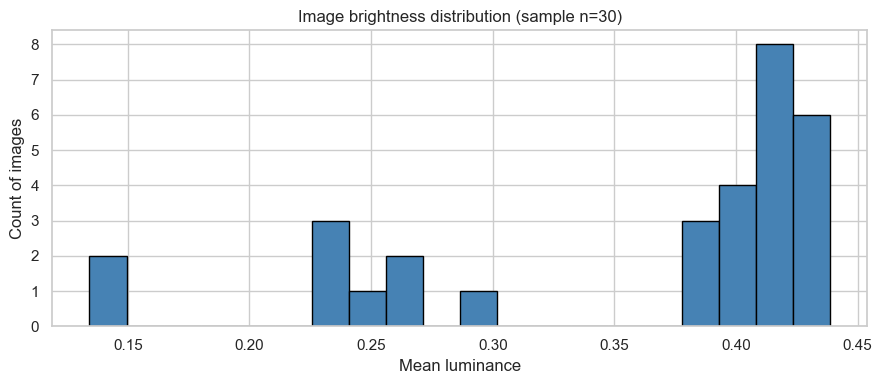

In [9]:
# Visualise brightness histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(brightness_vals, bins=20, color='steelblue', edgecolor='black')
ax.set_xlabel('Mean luminance')
ax.set_ylabel('Count of images')
ax.set_title(f'Image brightness distribution (sample n={len(brightness_vals)})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'brightness_hist.png', bbox_inches='tight')
plt.show()

## 5. Sample Images Grid

A visual sanity check — spot-check a few images so we know what we're working with.

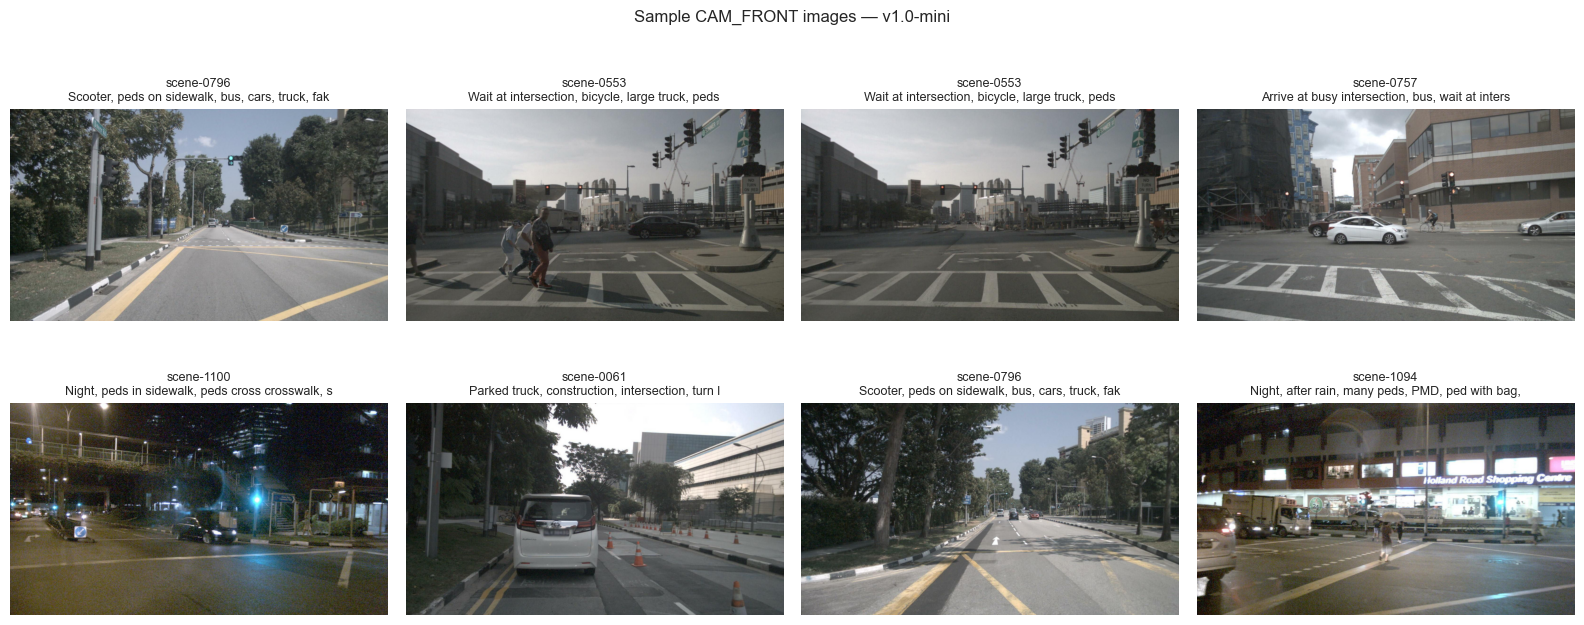

In [10]:
sample_indices = df_meta.sample(min(8, len(df_meta)), random_state=7).index.tolist()
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, idx in zip(axes.flatten(), sample_indices):
    img = Image.open(df_meta.loc[idx, 'image_path']).convert('RGB')
    ax.imshow(img)
    title = df_meta.loc[idx, 'scene_description'][:48]
    ax.set_title(f'{df_meta.loc[idx, "scene_name"]}\n{title}', fontsize=9)
    ax.axis('off')
plt.suptitle(f'Sample CAM_FRONT images — {DATASET_VERSION}', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'sample_images_grid.png', bbox_inches='tight')
plt.show()

## 6. Annotation Counts per Image

For the **vehicle density** and **VRU presence** attributes, we'll need annotation counts per keyframe. We compute them now.

In [11]:
# Categories of interest
VEHICLE_CATEGORIES = {
    'vehicle.car', 'vehicle.truck', 'vehicle.bus.bendy', 'vehicle.bus.rigid',
    'vehicle.construction', 'vehicle.emergency.police', 'vehicle.emergency.ambulance',
    'vehicle.trailer', 'vehicle.motorcycle', 'vehicle.bicycle',
}
VRU_CATEGORIES = {
    'human.pedestrian.adult', 'human.pedestrian.child',
    'human.pedestrian.construction_worker', 'human.pedestrian.police_officer',
    'human.pedestrian.stroller', 'human.pedestrian.wheelchair',
    'human.pedestrian.personal_mobility',
    'vehicle.bicycle', 'vehicle.motorcycle',
}
# Note: bicycle/motorcycle appear in both — they are vehicles AND VRUs.

print(f'Vehicle categories considered: {len(VEHICLE_CATEGORIES)}')
print(f'VRU categories considered:     {len(VRU_CATEGORIES)}')

Vehicle categories considered: 10
VRU categories considered:     9


In [12]:
# Helper: forward-cone filter — only count annotations roughly in front of the ego
def is_in_forward_cone(ann_record, sample_record, max_dist_m=50.0, half_angle_deg=30.0):
    """
    Approximate forward-cone test using ego position from CAM_FRONT sample_data.
    True if annotation is within ±half_angle_deg of the camera's heading and within max_dist_m.
    """
    cam_sd = nusc.get('sample_data', sample_record['data']['CAM_FRONT'])
    ego = nusc.get('ego_pose', cam_sd['ego_pose_token'])
    ex, ey = ego['translation'][:2]
    ax_, ay_ = ann_record['translation'][:2]
    dx, dy = ax_ - ex, ay_ - ey
    dist = np.hypot(dx, dy)
    if dist > max_dist_m:
        return False
    # Ego heading from quaternion (rough yaw extraction)
    from pyquaternion import Quaternion
    q = Quaternion(ego['rotation'])
    yaw = np.arctan2(2*(q[0]*q[3] + q[1]*q[2]), 1 - 2*(q[2]**2 + q[3]**2))
    obj_angle = np.arctan2(dy, dx)
    rel = np.degrees(obj_angle - yaw)
    rel = (rel + 180) % 360 - 180  # wrap to (-180, 180]
    return abs(rel) <= half_angle_deg

# Per-keyframe counts
veh_counts = []
vru_counts = []
for sample in nusc.sample:
    n_veh = 0; n_vru = 0
    for ann_token in sample['anns']:
        ann = nusc.get('sample_annotation', ann_token)
        if not is_in_forward_cone(ann, sample): 
            continue
        cat = ann['category_name']
        if cat in VEHICLE_CATEGORIES:
            n_veh += 1
        if cat in VRU_CATEGORIES:
            n_vru += 1
    veh_counts.append(n_veh)
    vru_counts.append(n_vru)

df_meta['veh_count_fwd'] = veh_counts
df_meta['vru_count_fwd'] = vru_counts

print(f'Vehicle-count distribution (forward cone):')
print(df_meta['veh_count_fwd'].describe().round(1))
print(f'\nVRU-count distribution (forward cone):')
print(df_meta['vru_count_fwd'].describe().round(1))

Vehicle-count distribution (forward cone):
count    404.0
mean       4.3
std        3.5
min        0.0
25%        2.0
50%        3.0
75%        6.0
max       16.0
Name: veh_count_fwd, dtype: float64

VRU-count distribution (forward cone):
count    404.0
mean       2.5
std        4.1
min        0.0
25%        0.0
50%        1.0
75%        3.0
max       22.0
Name: vru_count_fwd, dtype: float64


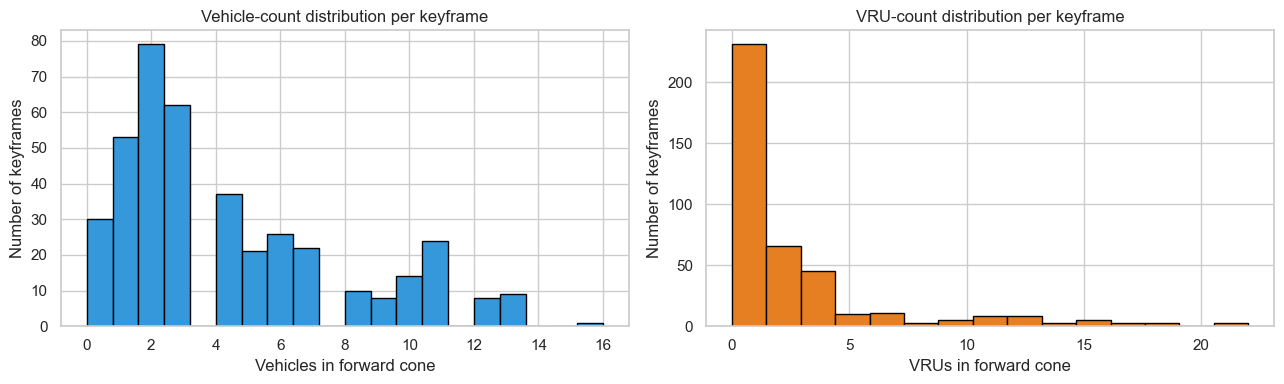

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_meta['veh_count_fwd'], bins=20, color='#3498db', edgecolor='black')
axes[0].set_xlabel('Vehicles in forward cone')
axes[0].set_ylabel('Number of keyframes')
axes[0].set_title('Vehicle-count distribution per keyframe')

axes[1].hist(df_meta['vru_count_fwd'], bins=15, color='#e67e22', edgecolor='black')
axes[1].set_xlabel('VRUs in forward cone')
axes[1].set_ylabel('Number of keyframes')
axes[1].set_title('VRU-count distribution per keyframe')

plt.tight_layout()
plt.savefig(FIG_DIR / 'count_distributions.png', bbox_inches='tight')
plt.show()

## 7. Save Enriched Metadata

This metadata file feeds notebook 02 (label generation).

In [14]:
df_meta.to_csv(META_DIR / 'sample_metadata_enriched.csv', index=False)
print(f'Saved enriched metadata → {META_DIR / "sample_metadata_enriched.csv"}')
print(f'Columns: {list(df_meta.columns)}')

Saved enriched metadata → data/metadata/sample_metadata_enriched.csv
Columns: ['sample_token', 'scene_token', 'scene_name', 'scene_description', 'location', 'vehicle', 'date_captured', 'image_path', 'image_filename', 'timestamp', 'desc_lower', 'veh_count_fwd', 'vru_count_fwd']


---
## Findings & Decisions (fill in after running)

**Dataset structure**
- v1.0-mini: 10 scenes × ~40 keyframes = ~404 CAM_FRONT images.
- Image dimensions: 1600 × 900 (consistent across all keyframes).
- All images RGB, 8-bit, JPG.

**Attribute label feasibility from this data**
- *Time of day*: derivable from scene description text + brightness statistics.
- *Weather*: derivable from scene description text + visual evidence.
- *Vehicle density*: derive thresholds from forward-cone vehicle count distribution (see section 6).
- *VRU presence*: derive from forward-cone VRU count > 0.

**Class balance concerns**
- Mini set may have very few night / rain examples — to be assessed in notebook 02.
- Vehicle density bins should be chosen via tertile thresholds on the count distribution.

**Implications for next phase**
- Move to notebook 02 to formalise the four attribute labels.
- Image preprocessing: 1600×900 → resize to 224×224 for feature extraction is reasonable.
- Brightness statistics in section 4 confirm that day-vs-night will likely be highly separable from luma alone.
